# MLP and CNN experiment report

This notebook loads the saved JSON files from `results/` and keeps the MLP and CNN experiments separate. Plot titles and summary tables include the architecture, dataset, and run id so it is clear which experiment produced each curve.


In [9]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


RESULTS_DIR = Path("results")
result_paths = sorted(RESULTS_DIR.glob("*.json"))

result_paths


[WindowsPath('results/cnn_cifar10_20260511_124835.json'),
 WindowsPath('results/cnn_fashionmnist_20260511_122614.json'),
 WindowsPath('results/cnn_mnist_20260511_120918.json'),
 WindowsPath('results/mlp_cifar10_20260511_132119.json'),
 WindowsPath('results/mlp_fashionmnist_20260511_130647.json'),
 WindowsPath('results/mlp_mnist_20260511_125754.json')]

## Load and organize results


In [10]:
METHOD_LABELS = {
    "mono_ff": "MonoFWD FF",
    "mono_bp": "MonoFWD BP",
    "bp": "Backprop",
}

MODEL_LABELS = {
    "mlp": "MLP",
    "cnn": "CNN",
}

DATASET_LABELS = {
    "mnist": "MNIST",
    "fashionmnist": "Fashion-MNIST",
    "cifar10": "CIFAR-10",
    "cifar100": "CIFAR-100",
}


def parse_result_filename(path: Path) -> tuple[str, str, str]:
    model, dataset, *run_parts = path.stem.split("_")
    return model, dataset, "_".join(run_parts)


def load_experiment_history(path: Path) -> pd.DataFrame:
    with path.open() as f:
        raw = json.load(f)

    model, dataset, run_id = parse_result_filename(path)
    model_label = MODEL_LABELS.get(model, model.upper())
    dataset_label = DATASET_LABELS.get(dataset, dataset.upper())

    rows = []
    for method, metrics in raw.items():
        if method not in METHOD_LABELS:
            continue

        max_train_epoch = len(metrics.get("train_losses", []))
        for metric, values in metrics.items():
            if not isinstance(values, list):
                continue

            is_final_test_metric = metric.startswith("test_") and len(values) == 1
            for index, value in enumerate(values, start=1):
                epoch = max_train_epoch if is_final_test_metric else index
                rows.append(
                    {
                        "file": path.name,
                        "model": model,
                        "model_label": model_label,
                        "dataset": dataset,
                        "dataset_label": dataset_label,
                        "run_id": run_id,
                        "experiment": f"{model_label} / {dataset_label} / {run_id}",
                        "method": method,
                        "method_label": METHOD_LABELS[method],
                        "metric": metric,
                        "epoch": epoch,
                        "value": value,
                        "is_final_test": is_final_test_metric,
                    }
                )

    return pd.DataFrame(rows)


history = pd.concat(
    [load_experiment_history(path) for path in result_paths],
    ignore_index=True,
)

losses = (
    history[history["metric"].isin(["train_losses", "val_losses", "test_losses"])]
    .copy()
    .assign(split=lambda df: df["metric"].str.replace("_losses", "", regex=False))
)

accuracies = (
    history[history["metric"].isin(["train_accs", "val_accs", "test_accs"])]
    .copy()
    .assign(split=lambda df: df["metric"].str.replace("_accs", "", regex=False))
)

display(losses.head())
display(
    history[history["metric"].str.startswith("train_")]
    .groupby(["model_label", "dataset_label", "run_id", "method_label"])["epoch"]
    .max()
    .rename("trained_epochs")
    .to_frame()
)


,file,model,model_label,dataset,dataset_label,run_id,experiment,method,method_label,metric,epoch,value,is_final_test,split
0,cnn_cifar10_20260511_124835.json,cnn,CNN,cifar10,CIFAR-10,20260511_124835,CNN / CIFAR-10 / 20260511_124835,mono_ff,MonoFWD FF,train_losses,1,2.329503,False,train
1,cnn_cifar10_20260511_124835.json,cnn,CNN,cifar10,CIFAR-10,20260511_124835,CNN / CIFAR-10 / 20260511_124835,mono_ff,MonoFWD FF,train_losses,2,1.922685,False,train
2,cnn_cifar10_20260511_124835.json,cnn,CNN,cifar10,CIFAR-10,20260511_124835,CNN / CIFAR-10 / 20260511_124835,mono_ff,MonoFWD FF,train_losses,3,1.798640,False,train
3,cnn_cifar10_20260511_124835.json,cnn,CNN,cifar10,CIFAR-10,20260511_124835,CNN / CIFAR-10 / 20260511_124835,mono_ff,MonoFWD FF,train_losses,4,1.703425,False,train
4,cnn_cifar10_20260511_124835.json,cnn,CNN,cifar10,CIFAR-10,20260511_124835,CNN / CIFAR-10 / 20260511_124835,mono_ff,MonoFWD FF,train_losses,5,1.641926,False,train


trained_epochs
model_label dataset_label run_id          method_label                
CNN         CIFAR-10      20260511_124835 Backprop                 100
                                          MonoFWD BP               100
                                          MonoFWD FF               100
            Fashion-MNIST 20260511_122614 Backprop                 100
                                          MonoFWD BP               100
                                          MonoFWD FF               100
            MNIST         20260511_120918 Backprop                 100
                                          MonoFWD BP               100
                                          MonoFWD FF               100
MLP         CIFAR-10      20260511_132119 Backprop                 100
                                          MonoFWD BP               100
                                          MonoFWD FF               100
            Fashion-MNIST 20260511_130647 Backprop                 100
                                          MonoFWD BP               100
                                          MonoFWD FF               100
            MNIST         20260511_125754 Backprop                 100
                                          MonoFWD BP               100
                                          MonoFWD FF               100

## Loss curves


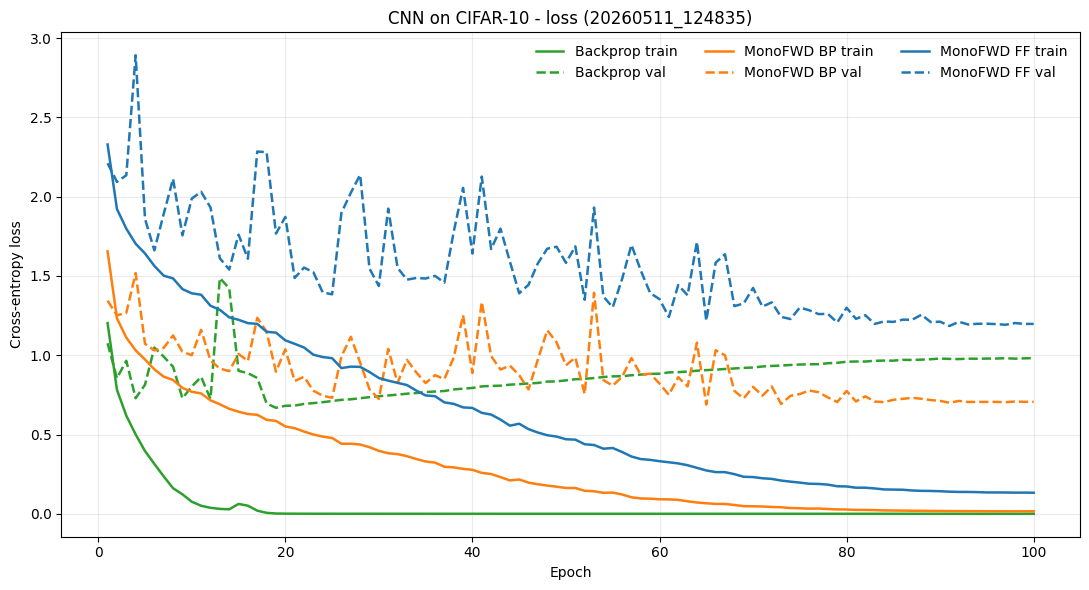

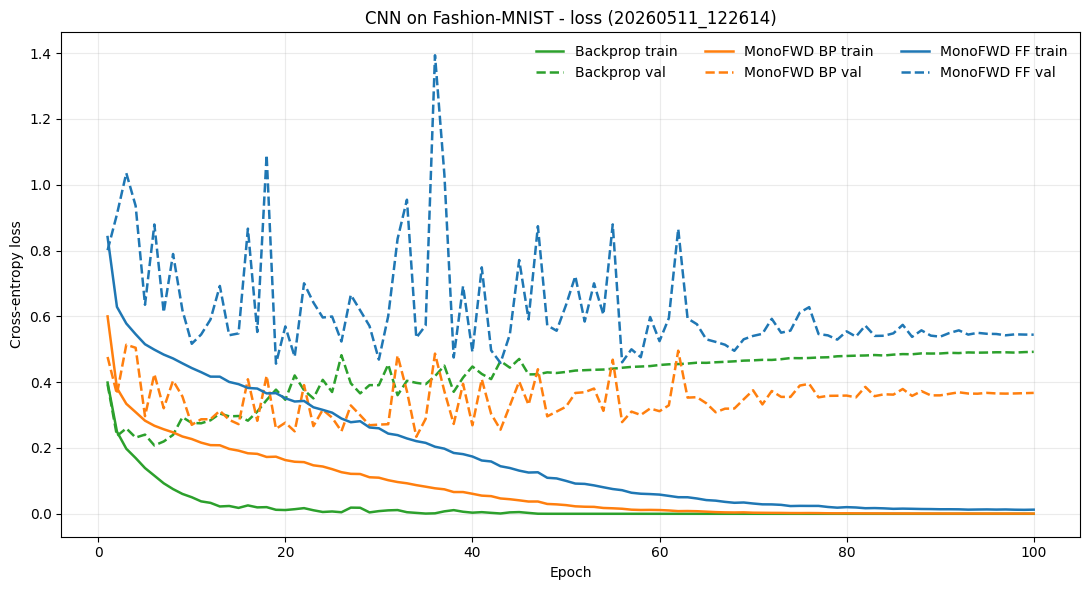

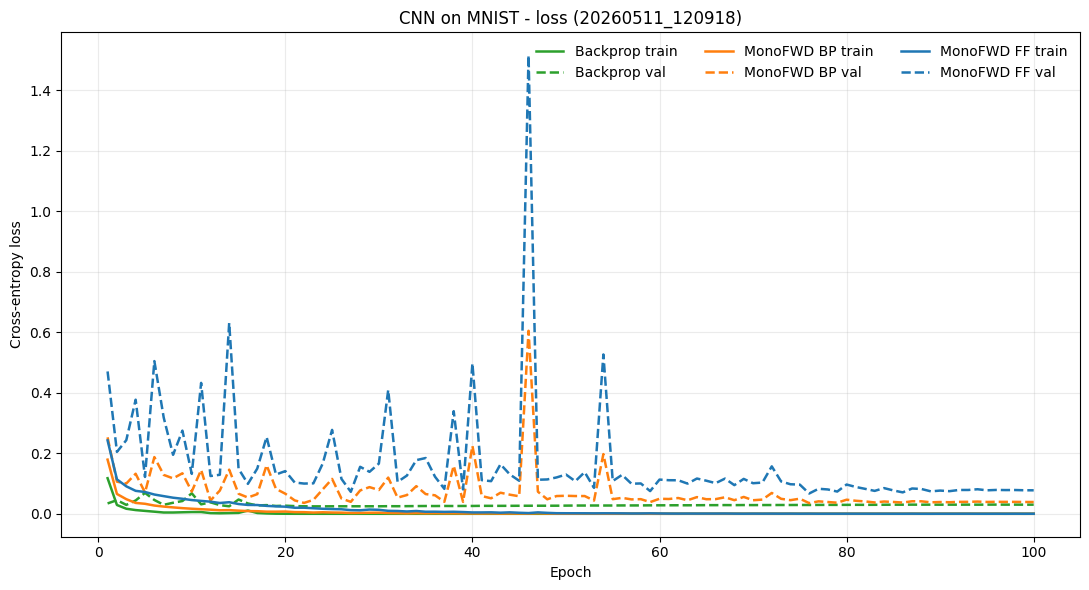

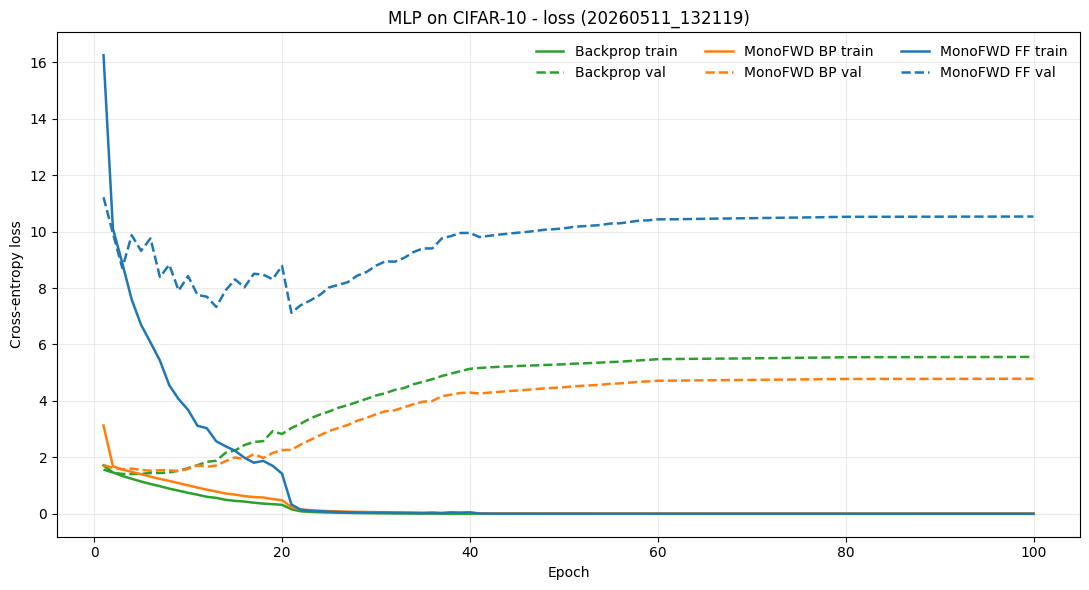

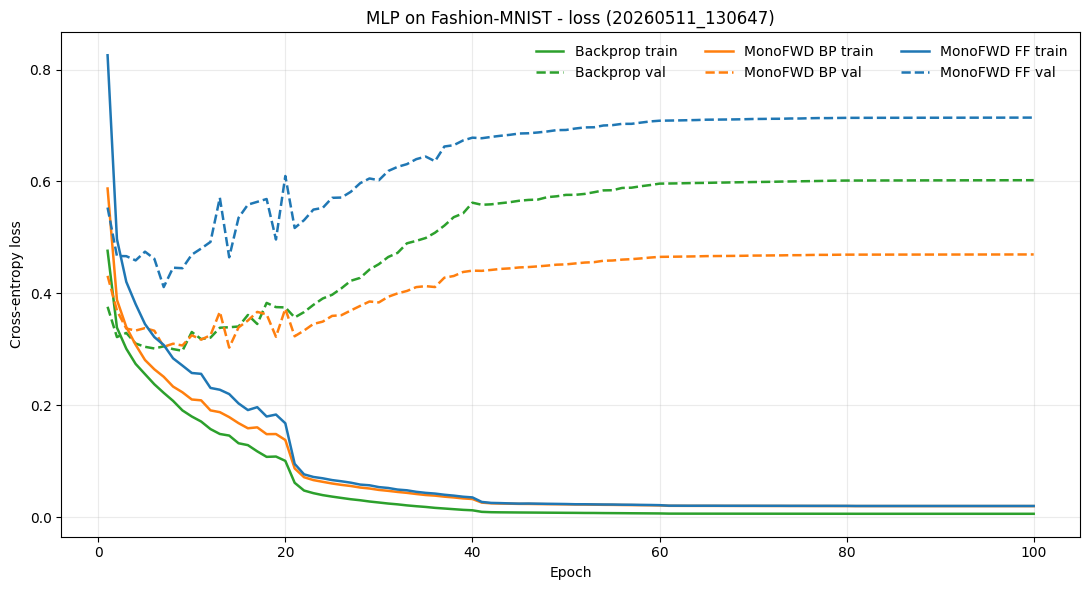

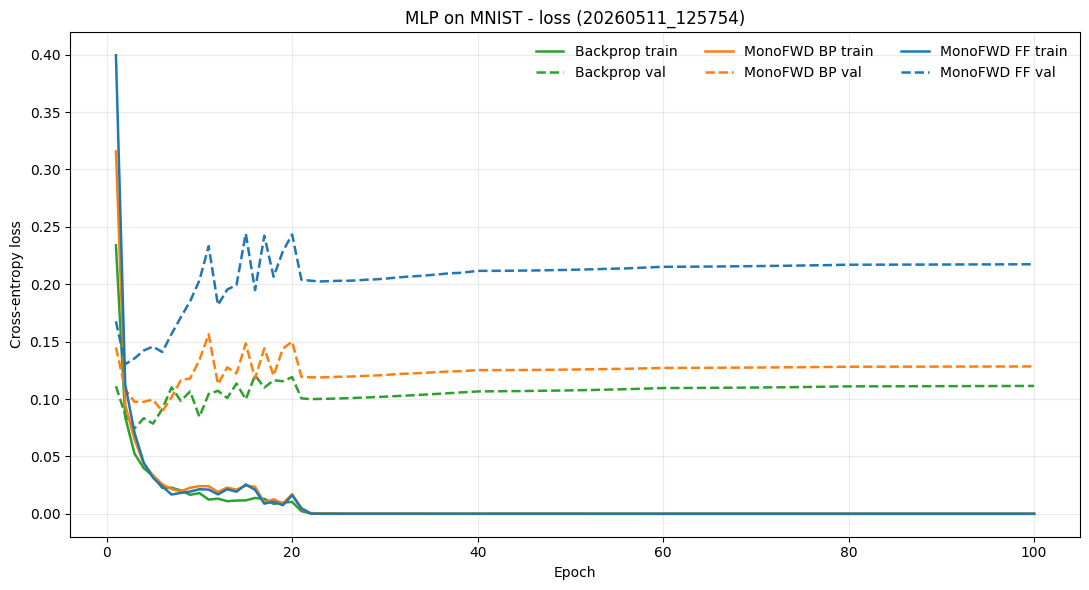

,model_label,dataset_label,run_id,method_label,test_loss
1204,CNN,CIFAR-10,20260511_124835,Backprop,1.011262
802,CNN,CIFAR-10,20260511_124835,MonoFWD BP,0.742836
400,CNN,CIFAR-10,20260511_124835,MonoFWD FF,1.252521
2410,CNN,Fashion-MNIST,20260511_122614,Backprop,0.562400
2008,CNN,Fashion-MNIST,20260511_122614,MonoFWD BP,0.456533
1606,CNN,Fashion-MNIST,20260511_122614,MonoFWD FF,0.695393
3616,CNN,MNIST,20260511_120918,Backprop,0.025298
3214,CNN,MNIST,20260511_120918,MonoFWD BP,0.042970
2812,CNN,MNIST,20260511_120918,MonoFWD FF,0.087256
4822,MLP,CIFAR-10,20260511_132119,Backprop,5.421368


In [11]:
method_colors = {
    "MonoFWD FF": "tab:blue",
    "MonoFWD BP": "tab:orange",
    "Backprop": "tab:green",
}
split_styles = {"train": "-", "val": "--", "test": "None"}
split_markers = {"train": None, "val": None, "test": "o"}

loss_groups = losses[losses["split"] != "test"].groupby(
    ["model_label", "dataset_label", "run_id"],
    sort=True,
)

for (model_label, dataset_label, run_id), experiment_losses in loss_groups:
    fig, ax = plt.subplots(figsize=(11, 6))

    for (method_label, split), group in experiment_losses.groupby(
        ["method_label", "split"],
        sort=True,
    ):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            marker=split_markers[split],
            linewidth=1.8,
            label=f"{method_label} {split}",
        )

    ax.set_title(f"{model_label} on {dataset_label} - loss ({run_id})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()

test_loss_summary = (
    losses[losses["split"] == "test"]
    .sort_values(["model_label", "dataset_label", "run_id", "method_label"])[
        ["model_label", "dataset_label", "run_id", "method_label", "value"]
    ]
    .rename(columns={"value": "test_loss"})
)

display(test_loss_summary)


## Accuracy curves


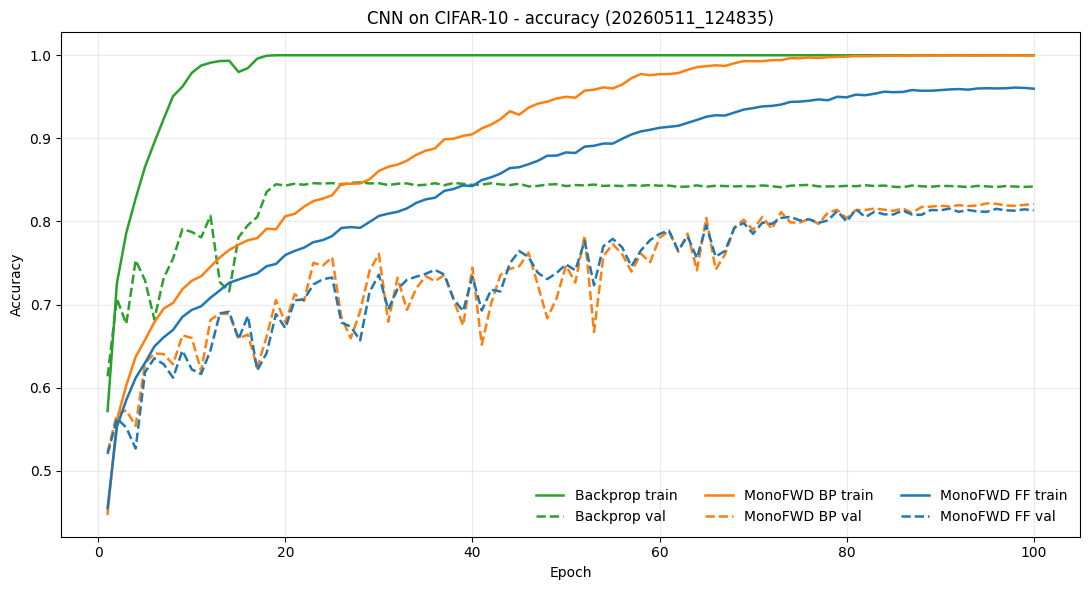

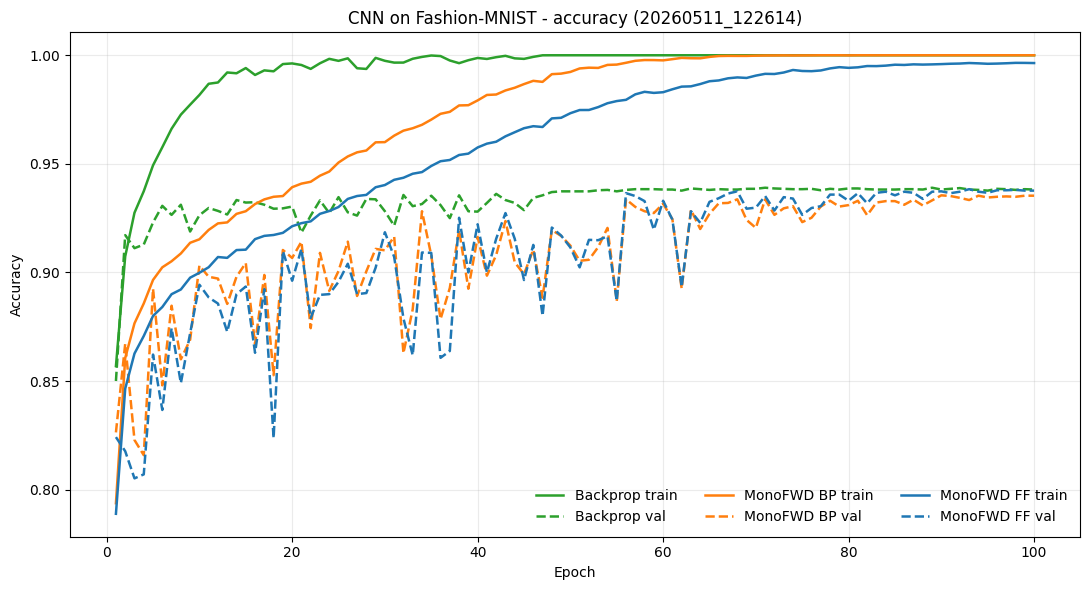

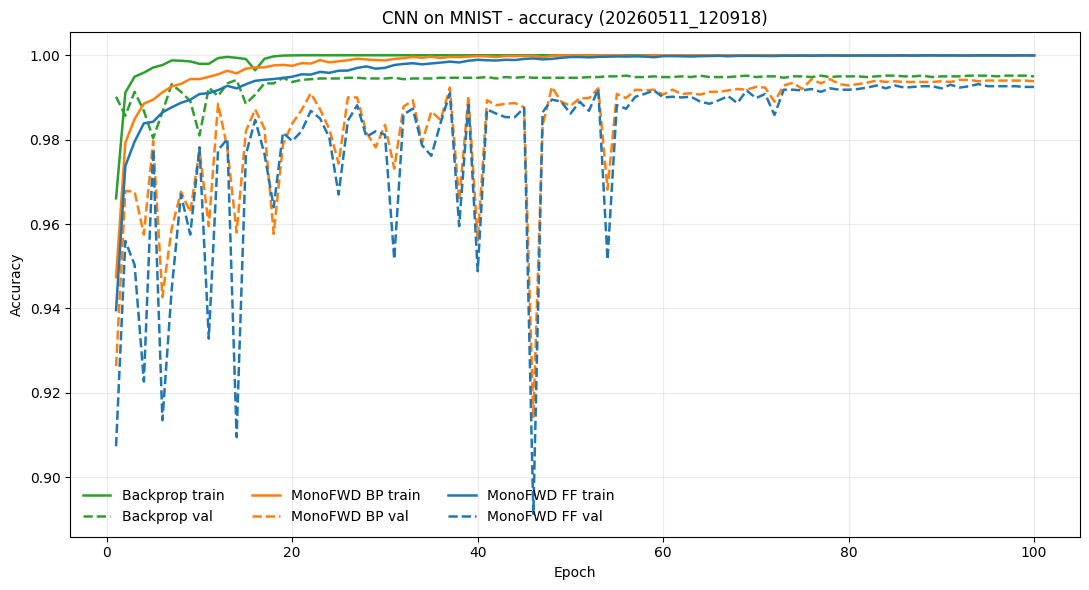

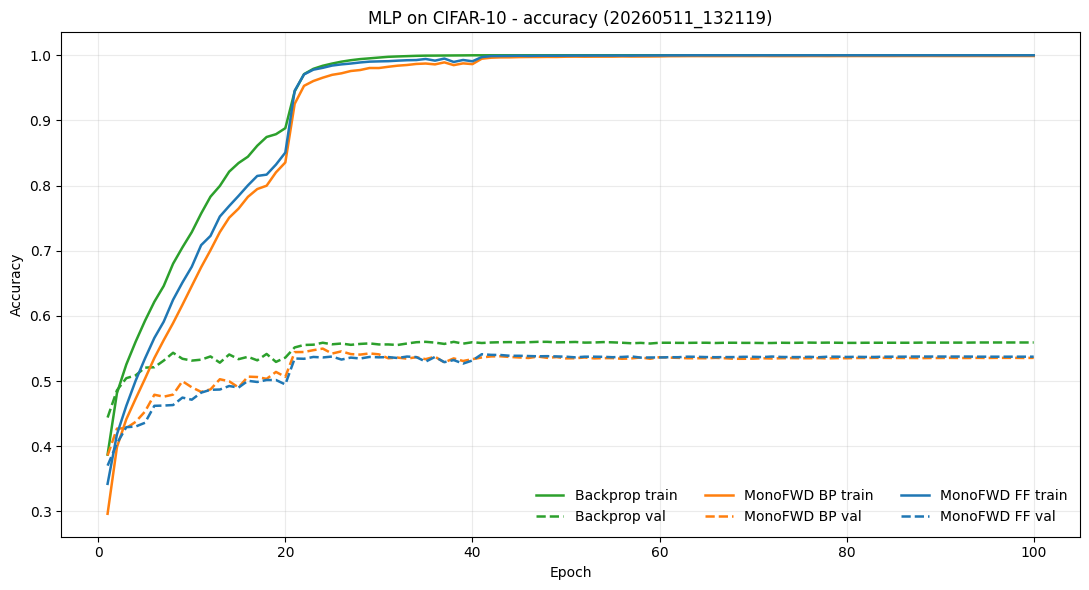

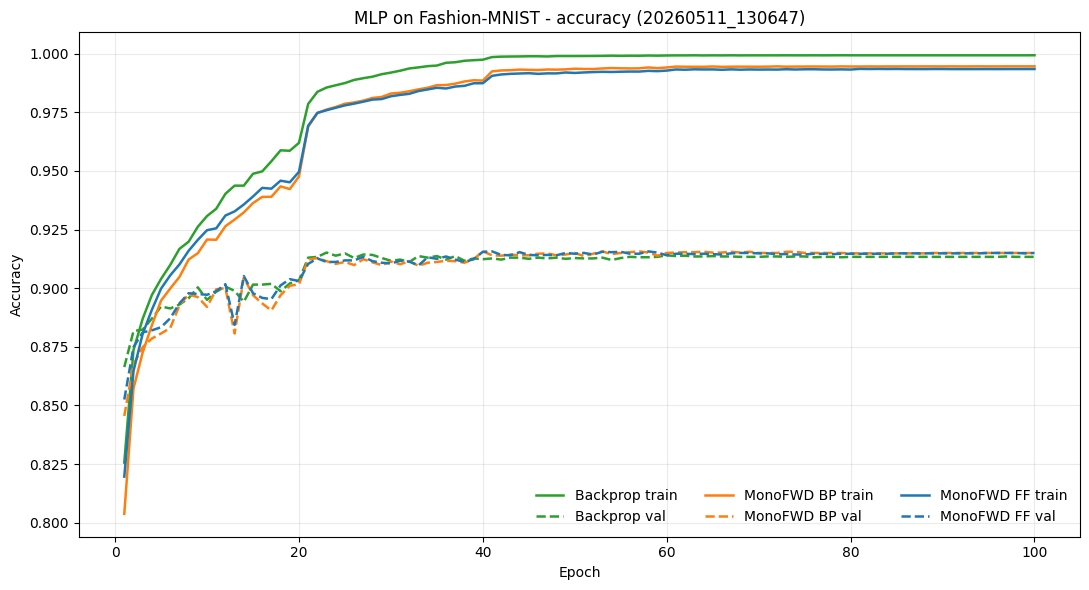

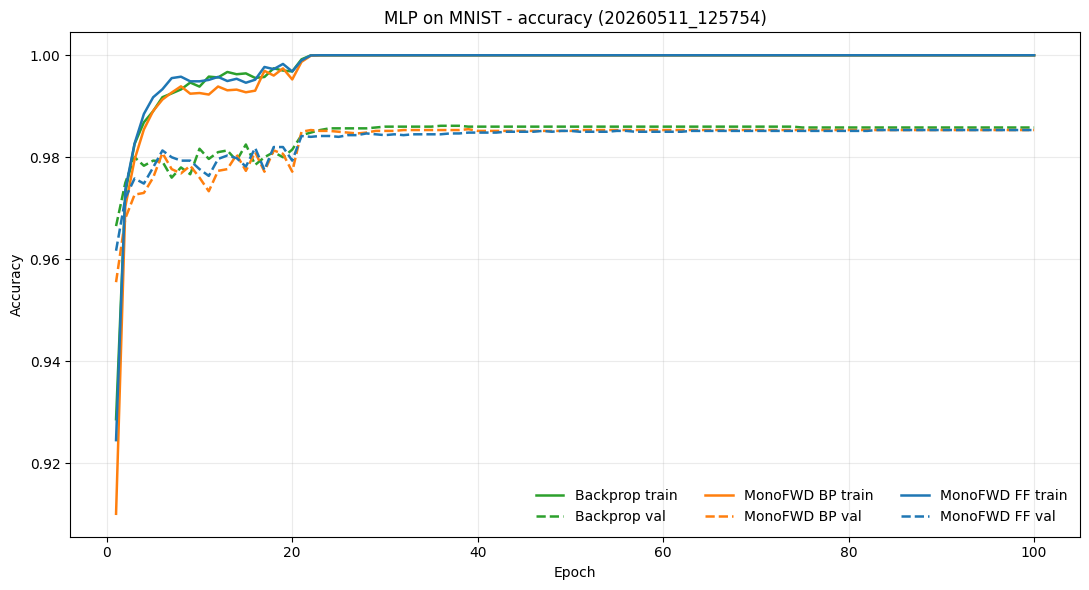

,model_label,dataset_label,run_id,method_label,test_accuracy
1205,CNN,CIFAR-10,20260511_124835,Backprop,0.8352
803,CNN,CIFAR-10,20260511_124835,MonoFWD BP,0.8109
401,CNN,CIFAR-10,20260511_124835,MonoFWD FF,0.8101
2411,CNN,Fashion-MNIST,20260511_122614,Backprop,0.9307
2009,CNN,Fashion-MNIST,20260511_122614,MonoFWD BP,0.9198
1607,CNN,Fashion-MNIST,20260511_122614,MonoFWD FF,0.9224
3617,CNN,MNIST,20260511_120918,Backprop,0.9952
3215,CNN,MNIST,20260511_120918,MonoFWD BP,0.9926
2813,CNN,MNIST,20260511_120918,MonoFWD FF,0.9915
4823,MLP,CIFAR-10,20260511_132119,Backprop,0.5576


In [12]:
accuracy_groups = accuracies[accuracies["split"] != "test"].groupby(
    ["model_label", "dataset_label", "run_id"],
    sort=True,
)

for (model_label, dataset_label, run_id), experiment_accuracies in accuracy_groups:
    fig, ax = plt.subplots(figsize=(11, 6))

    for (method_label, split), group in experiment_accuracies.groupby(
        ["method_label", "split"],
        sort=True,
    ):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            marker=split_markers[split],
            linewidth=1.8,
            label=f"{method_label} {split}",
        )

    ax.set_title(f"{model_label} on {dataset_label} - accuracy ({run_id})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()

test_accuracy_summary = (
    accuracies[accuracies["split"] == "test"]
    .sort_values(["model_label", "dataset_label", "run_id", "method_label"])[
        ["model_label", "dataset_label", "run_id", "method_label", "value"]
    ]
    .rename(columns={"value": "test_accuracy"})
)

display(test_accuracy_summary)


## Averaged results across runs


In [13]:
import numpy as np

# Average losses across runs
avg_losses = (
    losses[losses["split"] != "test"]
    .groupby(
        ["model_label", "dataset_label", "method_label", "split", "epoch"],
        as_index=False,
    )
    .agg(
        value_mean=("value", "mean"),
        value_std=("value", "std"),
        count=("value", "count"),
    )
)

# Average accuracies across runs
avg_accuracies = (
    accuracies[accuracies["split"] != "test"]
    .groupby(
        ["model_label", "dataset_label", "method_label", "split", "epoch"],
        as_index=False,
    )
    .agg(
        value_mean=("value", "mean"),
        value_std=("value", "std"),
        count=("value", "count"),
    )
)

avg_losses

,model_label,dataset_label,method_label,split,epoch,value_mean,value_std,count
0,CNN,CIFAR-10,Backprop,train,1,1.203132,NaN,1
1,CNN,CIFAR-10,Backprop,train,2,0.782416,NaN,1
2,CNN,CIFAR-10,Backprop,train,3,0.619103,NaN,1
3,CNN,CIFAR-10,Backprop,train,4,0.500602,NaN,1
4,CNN,CIFAR-10,Backprop,train,5,0.395892,NaN,1
...,...,...,...,...,...,...,...,...
3595,MLP,MNIST,MonoFWD FF,val,96,0.217302,NaN,1
3596,MLP,MNIST,MonoFWD FF,val,97,0.217331,NaN,1
3597,MLP,MNIST,MonoFWD FF,val,98,0.217355,NaN,1
3598,MLP,MNIST,MonoFWD FF,val,99,0.217375,NaN,1


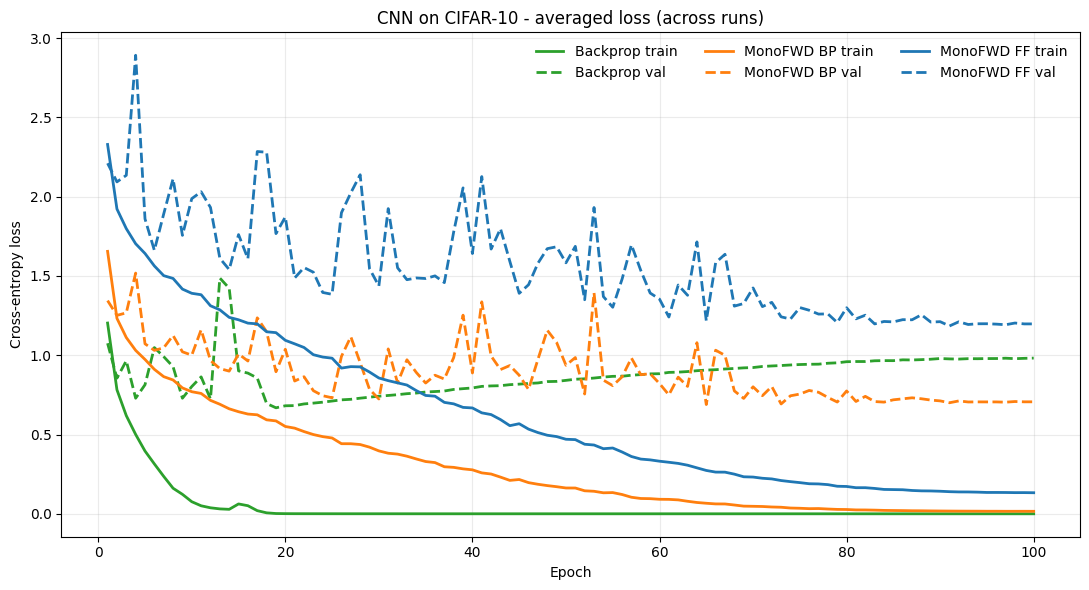

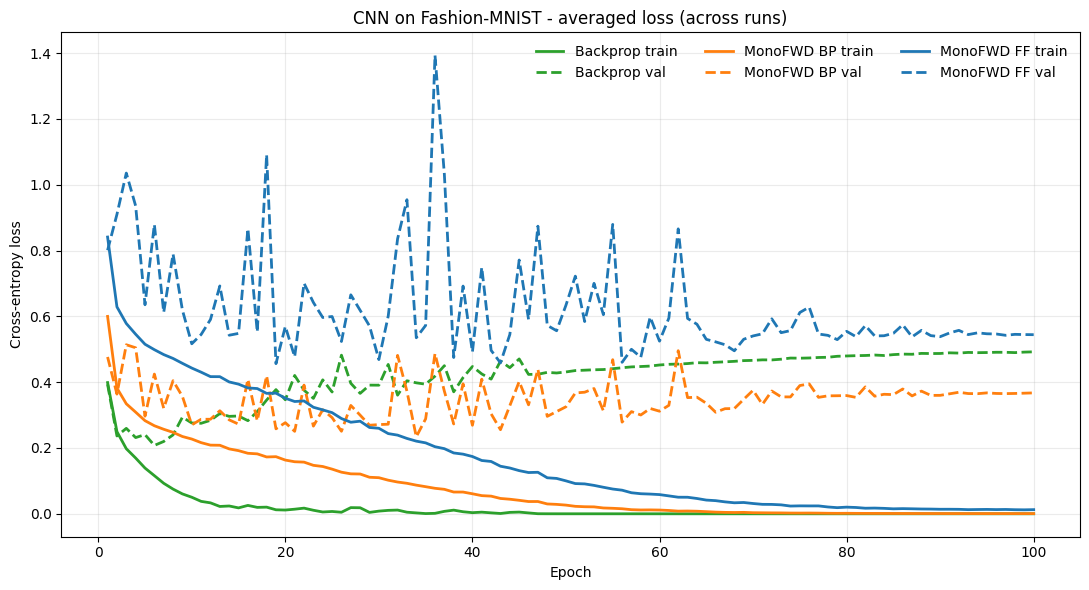

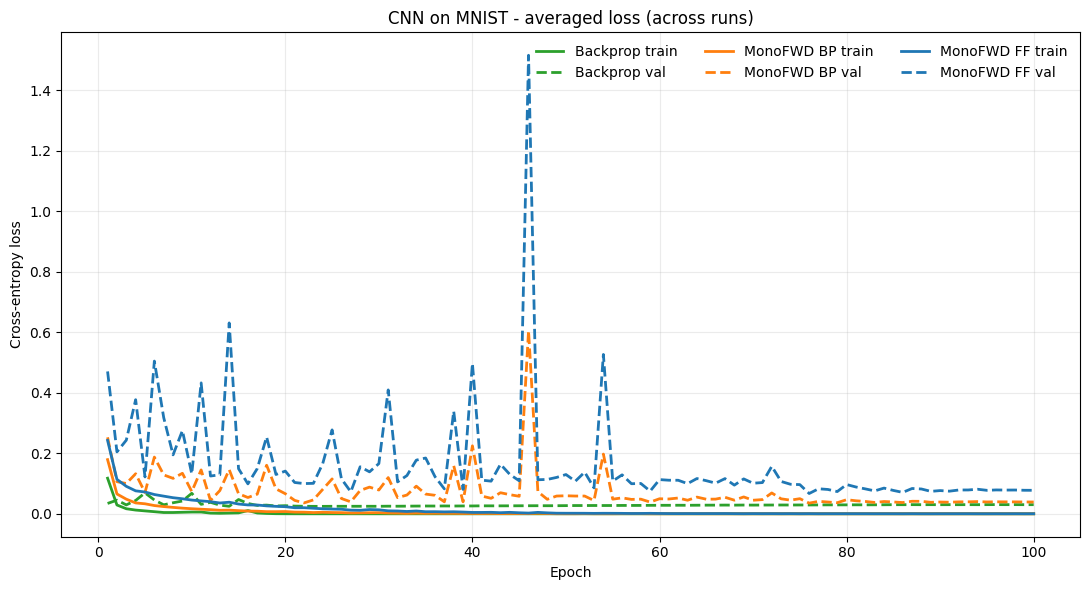

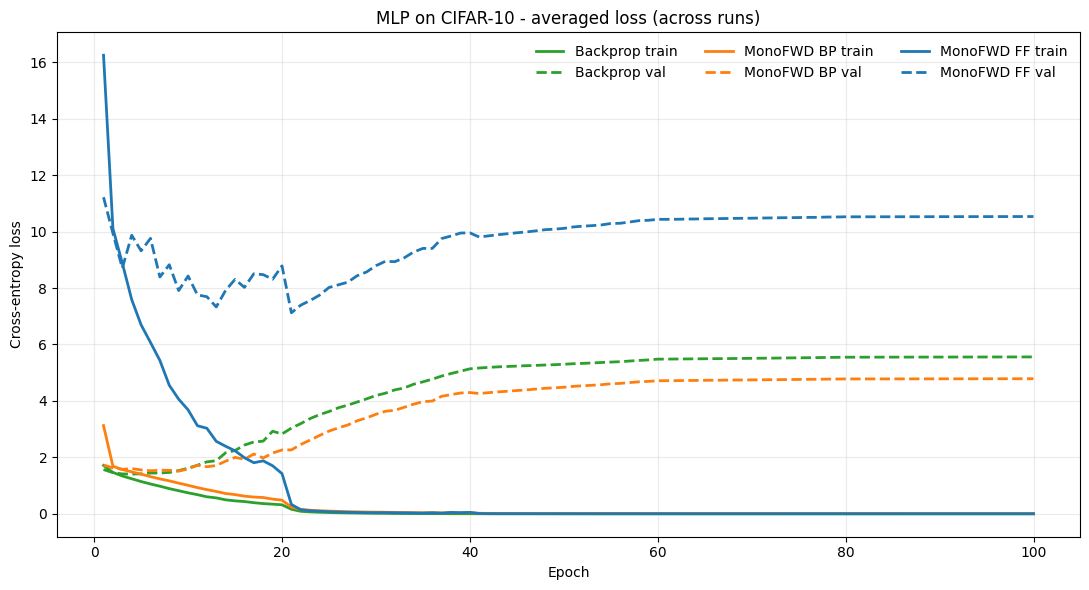

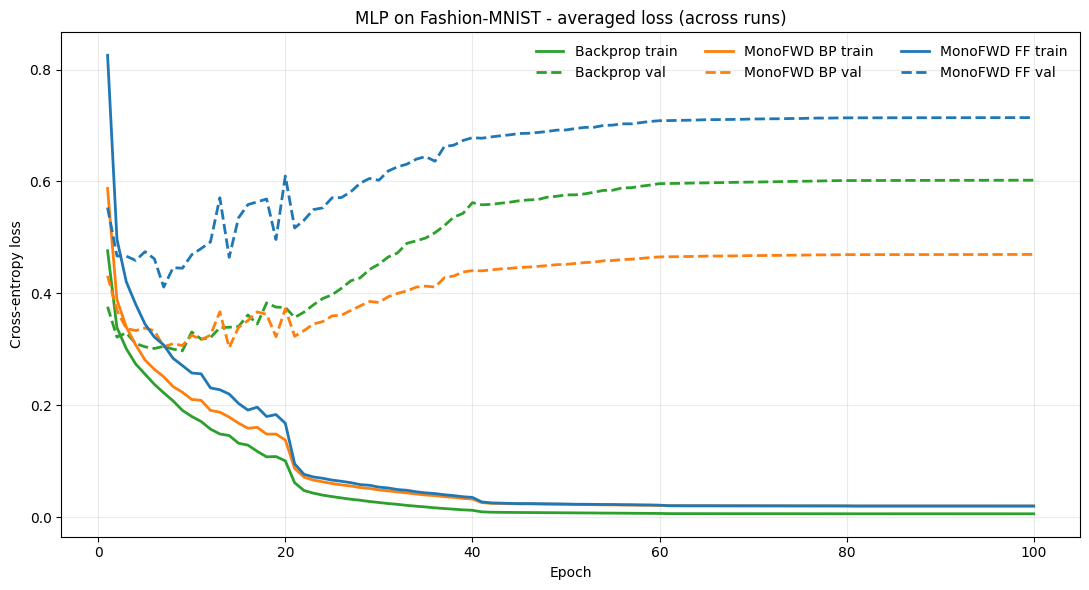

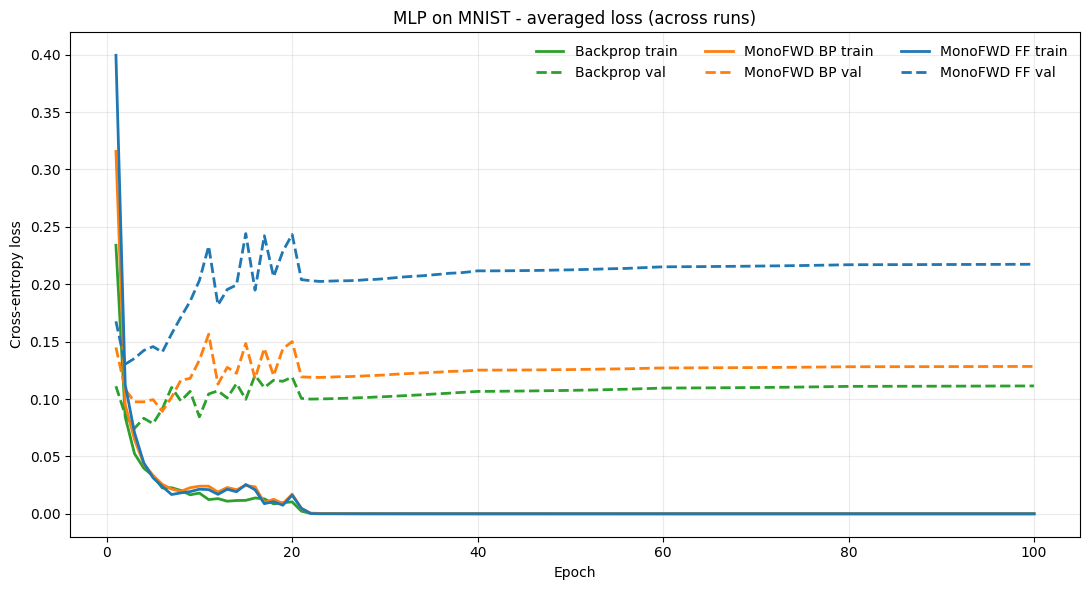

In [14]:
avg_loss_groups = avg_losses.groupby(
    ["model_label", "dataset_label"],
    sort=True,
)

for (model_label, dataset_label), model_losses in avg_loss_groups:
    fig, ax = plt.subplots(figsize=(11, 6))

    for (method_label, split), group in model_losses.groupby(
        ["method_label", "split"],
        sort=True,
    ):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value_mean"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            linewidth=2,
            label=f"{method_label} {split}",
        )

        # Add shaded region for ±1 std dev
        if group["value_std"].notna().any():
            ax.fill_between(
                group["epoch"],
                group["value_mean"] - group["value_std"],
                group["value_mean"] + group["value_std"],
                color=method_colors[method_label],
                alpha=0.15,
            )

    ax.set_title(f"{model_label} on {dataset_label} - averaged loss (across runs)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()

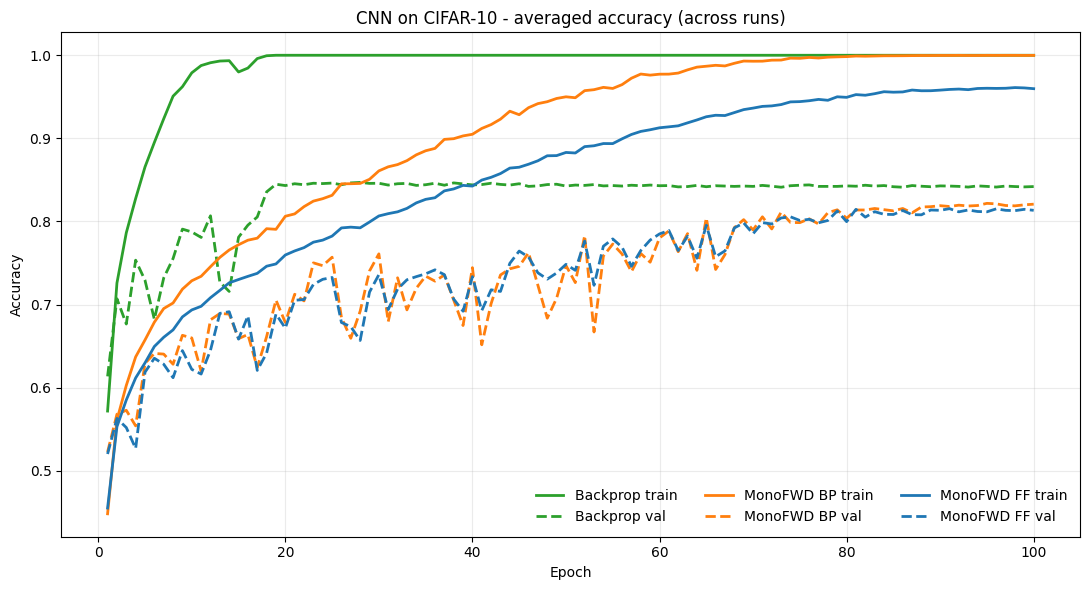

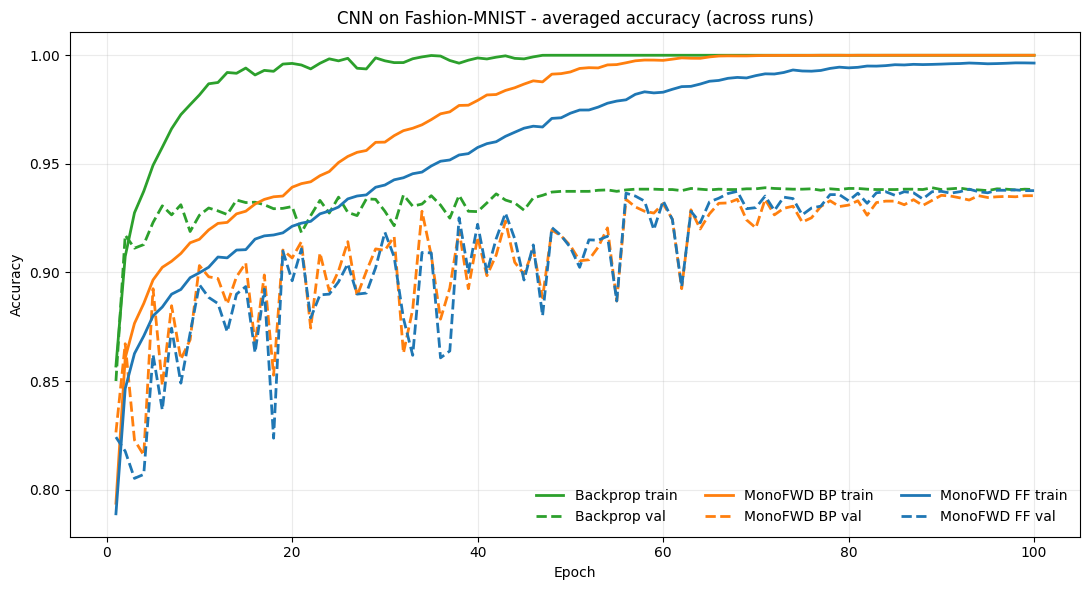

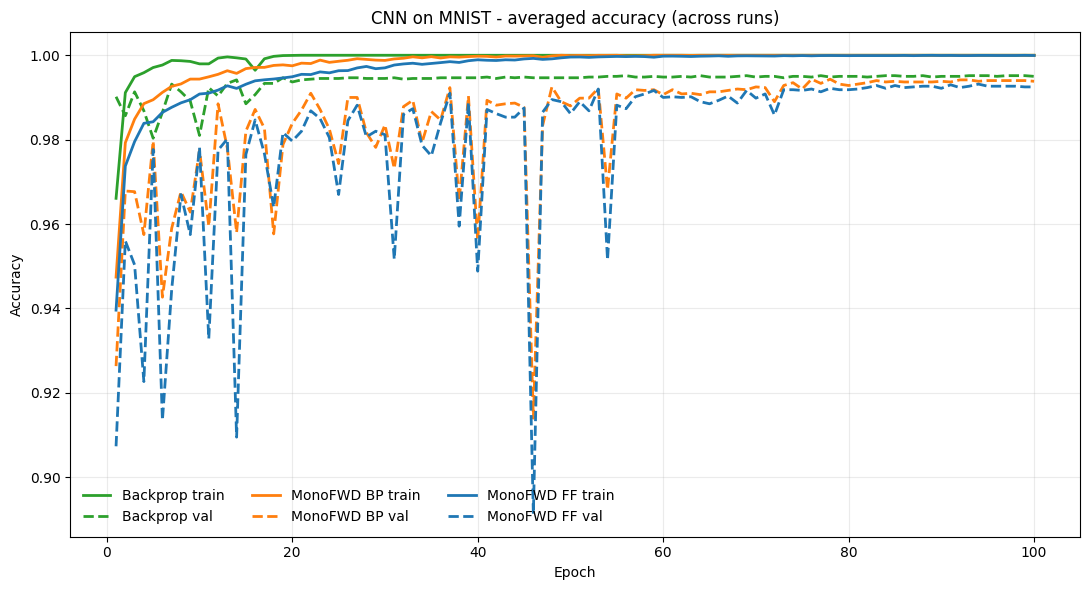

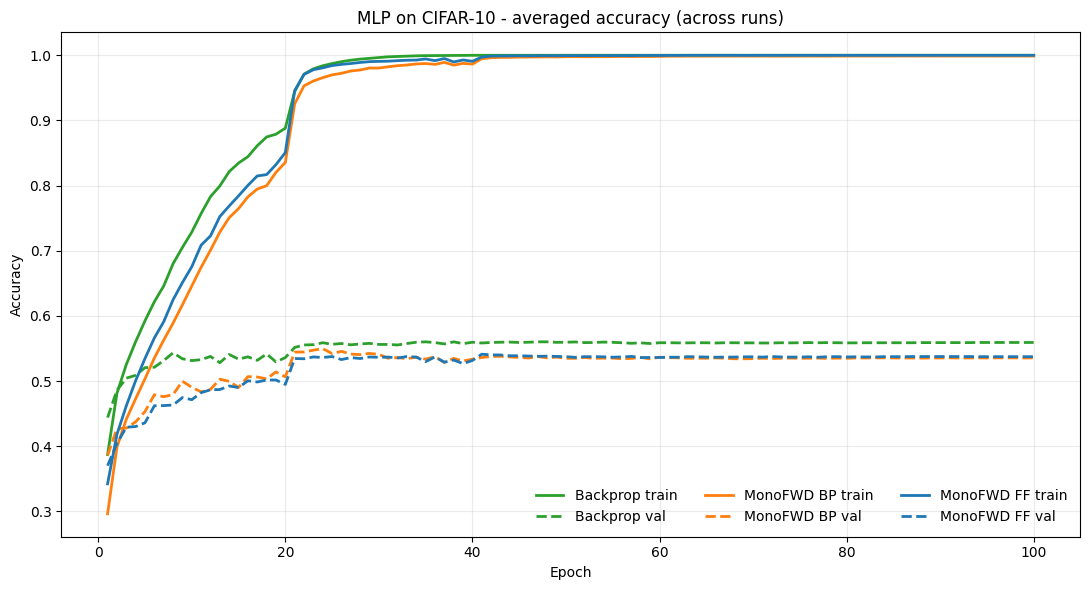

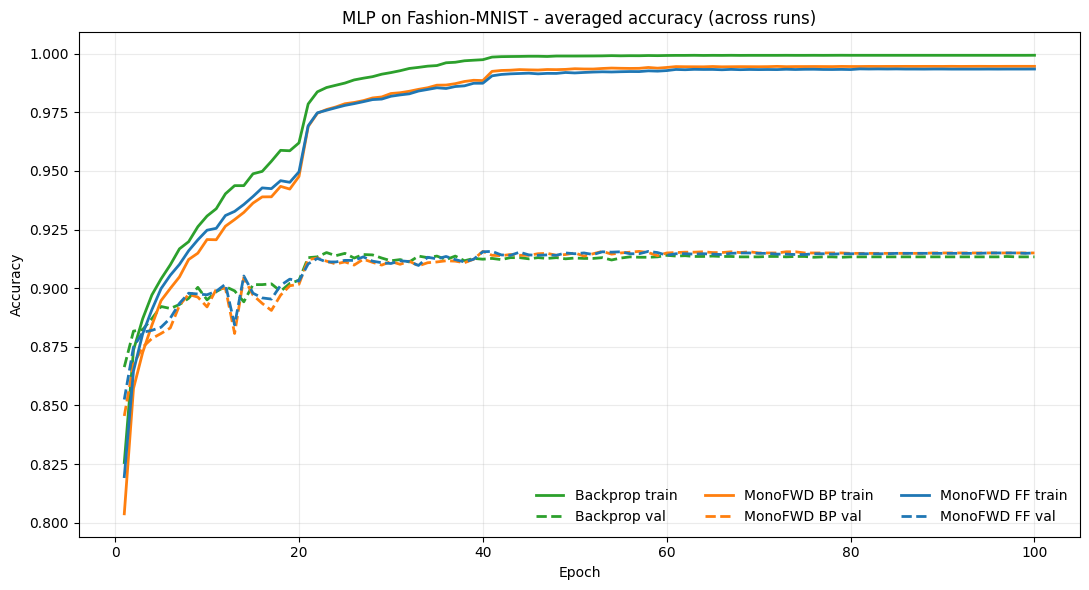

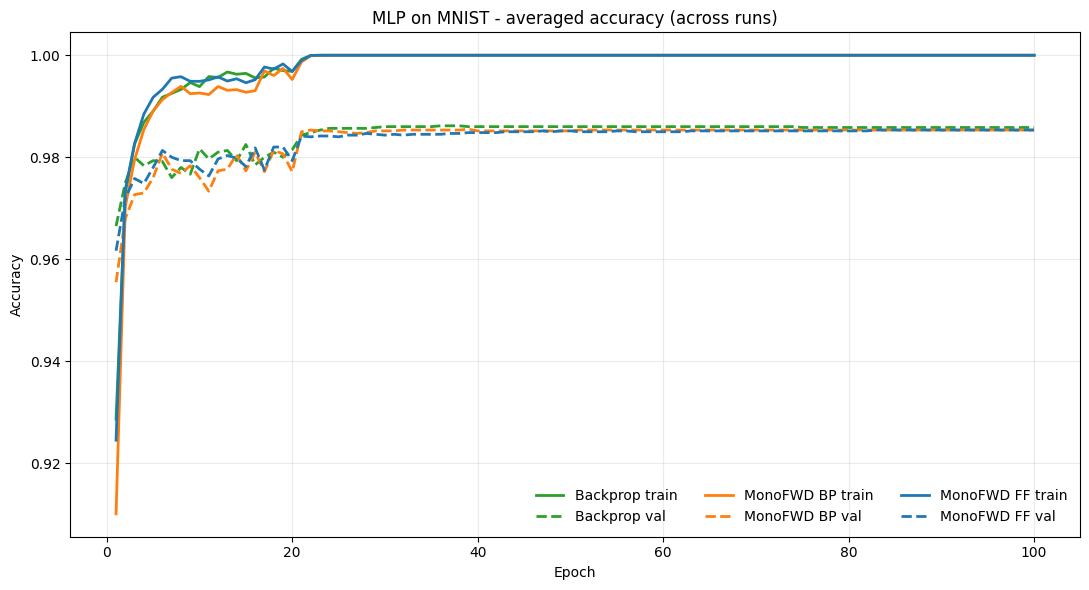

In [15]:
avg_accuracy_groups = avg_accuracies.groupby(
    ["model_label", "dataset_label"],
    sort=True,
)

for (model_label, dataset_label), model_accs in avg_accuracy_groups:
    fig, ax = plt.subplots(figsize=(11, 6))

    for (method_label, split), group in model_accs.groupby(
        ["method_label", "split"],
        sort=True,
    ):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value_mean"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            linewidth=2,
            label=f"{method_label} {split}",
        )

        # Add shaded region for ±1 std dev
        if group["value_std"].notna().any():
            ax.fill_between(
                group["epoch"],
                group["value_mean"] - group["value_std"],
                group["value_mean"] + group["value_std"],
                color=method_colors[method_label],
                alpha=0.15,
            )

    ax.set_title(f"{model_label} on {dataset_label} - averaged accuracy (across runs)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()

In [16]:
# Summary of averaged test metrics
avg_test_loss = (
    losses[losses["split"] == "test"]
    .groupby(["model_label", "dataset_label", "method_label"], as_index=False)
    .agg(
        test_loss_mean=("value", "mean"),
        test_loss_std=("value", "std"),
        count=("value", "count"),
    )
    .sort_values(["model_label", "dataset_label", "method_label"])
)

avg_test_accuracy = (
    accuracies[accuracies["split"] == "test"]
    .groupby(["model_label", "dataset_label", "method_label"], as_index=False)
    .agg(
        test_acc_mean=("value", "mean"),
        test_acc_std=("value", "std"),
        count=("value", "count"),
    )
    .sort_values(["model_label", "dataset_label", "method_label"])
)

display(
    avg_test_loss.rename(
        columns={"test_loss_mean": "loss", "test_loss_std": "loss_std"}
    )
)
display(
    avg_test_accuracy.rename(
        columns={"test_acc_mean": "accuracy", "test_acc_std": "accuracy_std"}
    )
)

,model_label,dataset_label,method_label,loss,loss_std,count
0,CNN,CIFAR-10,Backprop,1.011262,NaN,1
1,CNN,CIFAR-10,MonoFWD BP,0.742836,NaN,1
2,CNN,CIFAR-10,MonoFWD FF,1.252521,NaN,1
3,CNN,Fashion-MNIST,Backprop,0.562400,NaN,1
4,CNN,Fashion-MNIST,MonoFWD BP,0.456533,NaN,1
5,CNN,Fashion-MNIST,MonoFWD FF,0.695393,NaN,1
6,CNN,MNIST,Backprop,0.025298,NaN,1
7,CNN,MNIST,MonoFWD BP,0.042970,NaN,1
8,CNN,MNIST,MonoFWD FF,0.087256,NaN,1
9,MLP,CIFAR-10,Backprop,5.421368,NaN,1


,model_label,dataset_label,method_label,accuracy,accuracy_std,count
0,CNN,CIFAR-10,Backprop,0.8352,NaN,1
1,CNN,CIFAR-10,MonoFWD BP,0.8109,NaN,1
2,CNN,CIFAR-10,MonoFWD FF,0.8101,NaN,1
3,CNN,Fashion-MNIST,Backprop,0.9307,NaN,1
4,CNN,Fashion-MNIST,MonoFWD BP,0.9198,NaN,1
5,CNN,Fashion-MNIST,MonoFWD FF,0.9224,NaN,1
6,CNN,MNIST,Backprop,0.9952,NaN,1
7,CNN,MNIST,MonoFWD BP,0.9926,NaN,1
8,CNN,MNIST,MonoFWD FF,0.9915,NaN,1
9,MLP,CIFAR-10,Backprop,0.5576,NaN,1
